In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==============================================================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO
# ==============================================================================
import gc
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# Ruta al archivo parquet filtrado
path_parquet_1 = "/content/drive/MyDrive/Maestria Ingenieria y analitica de datos/semestre 4/proyecto de grado/fuentes de datos/base_finales/base_filtrada/"

print("Librerías cargadas exitosamente.")

Librerías cargadas exitosamente.


In [ ]:
# ==============================================================================
# PASO 2: CARGA SELECTIVA DE VARIABLES DE ESTUDIO
# ==============================================================================
selected_columns = [
    # Demográficas e individuales
    "estu_genero",
    "estu_fechanacimiento",
    "estu_horassemanatrabaja",
    "estu_dedicacioninternet",
    "estu_dedicacionlecturadiaria",
    # Socioeconómicas y familiares
    "fami_estratovivienda",
    "fami_educacionmadre",
    "estu_inse_individual",
    "estu_nse_establecimiento",
    "fami_personashogar",
    "fami_cuartoshogar",
    "fami_numlibros",
    "fami_trabajolabormadre",
    "fami_trabajolaborpadre",
    # Variables de bienes del hogar
    "fami_tieneautomovil",
    "fami_tienecomputador",
    "fami_tieneconsolavideojuegos",
    "fami_tienehornomicroogas",
    "fami_tieneinternet",
    "fami_tienelavadora",
    "fami_tienemotocicleta",
    "fami_tieneserviciotv",
    # Variables de consumo alimentario
    "fami_comecarnepescadohuevo",
    "fami_comecerealfrutoslegumbre",
    "fami_comelechederivados",
    # Institucionales y territoriales
    "cole_naturaleza",
    "cole_area_ubicacion",
    "cole_calendario",
    "cole_jornada",
    "cole_caracter",
    "cole_cod_mcpio_ubicacion",
    "estu_cod_reside_depto",
    "estu_cod_reside_mcpio",
    # Metadatos y objetivo
    "periodo",
    "punt_global",
]

df = pd.read_parquet(path_parquet_1, columns=selected_columns)
print(f"Dataset cargado: {df.shape[0]:,} filas y {df.shape[1]} columnas.")

Dataset cargado: 861,251 filas y 35 columnas.


In [ ]:
# ==============================================================================
# PASO 3: INGENIERÍA DE CARACTERÍSTICAS Y PREPARACIÓN DE DATOS
# ==============================================================================
# 3.1 Limpieza de la variable objetivo
df["punt_global"] = pd.to_numeric(df["punt_global"], errors="coerce")
df.dropna(subset=["punt_global"], inplace=True)

# 3.2 Cálculo de la edad y filtrado de rango coherente
df["ano_examen"] = df["periodo"].astype(str).str[:4].astype(int)
df["estu_fechanacimiento"] = pd.to_datetime(
    df["estu_fechanacimiento"], format="%d/%m/%Y", errors="coerce"
)
df["estu_edad"] = df["ano_examen"] - df["estu_fechanacimiento"].dt.year
df = df[(df["estu_edad"] >= 10) & (df["estu_edad"] <= 80)].copy()
df.drop(columns=["estu_fechanacimiento", "ano_examen", "periodo"], inplace=True)

# 3.3 Construcción del índice de bienes (0 a 8)
cols_bienes = [
    "fami_tieneautomovil",
    "fami_tienecomputador",
    "fami_tieneconsolavideojuegos",
    "fami_tienehornomicroogas",
    "fami_tieneinternet",
    "fami_tienelavadora",
    "fami_tienemotocicleta",
    "fami_tieneserviciotv",
]
for col in cols_bienes:
    df[col + "_bin"] = (df[col].astype(str).str.upper() == "SI").astype(
        np.int8
    )

df["indice_bienes"] = (
    df[[c + "_bin" for c in cols_bienes]].sum(axis=1).astype(np.int8)
)
df.drop(
    columns=cols_bienes + [c + "_bin" for c in cols_bienes], inplace=True
)

# 3.4 Construcción del índice de consumo alimentario (0 a 9)
map_consumo = {
    "Nunca o rara vez comemos eso": 0,
    "1 o 2 veces por semana": 1,
    "3 a 5 veces por semana": 2,
    "Todos o casi todos los días": 3,
}
cols_consumo = [
    "fami_comecarnepescadohuevo",
    "fami_comecerealfrutoslegumbre",
    "fami_comelechederivados",
]
for col in cols_consumo:
    df[col + "_num"] = df[col].map(map_consumo).fillna(0).astype(np.int8)

df["indice_consumo"] = (
    df[[c + "_num" for c in cols_consumo]].sum(axis=1).astype(np.int8)
)
df.drop(
    columns=cols_consumo + [c + "_num" for c in cols_consumo], inplace=True
)

print(
    f"Registros depurados listos para modelar: {df.shape[0]:,} observaciones."
)

Registros depurados listos para modelar: 859,949 observaciones.


In [ ]:
# ==============================================================================
# PASO 4 (CORREGIDO): CONTROL DE CARDINALIDAD Y PREPARACIÓN DE MATRICES
# ==============================================================================
# 1. Conversión de variables continuas y edad a float32
numeric_cols = [
    "estu_edad",
    "estu_inse_individual",
    "estu_nse_establecimiento",
    "indice_bienes",
    "indice_consumo"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(np.float32)

# 2. Identificar columnas categóricas
cat_cols = [col for col in df.columns if col not in numeric_cols and col != "punt_global"]

for col in cat_cols:
    df[col] = df[col].astype(str).fillna("MISSING")

# 3. Codificación Ordinal para todas las categóricas
ord_enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df[cat_cols] = ord_enc.fit_transform(df[cat_cols]).astype(np.int32)

# 4. Separación X / y
X = df.drop(columns=["punt_global"])
y = df["punt_global"].astype(np.float32)

del df
gc.collect()

# 5. Partición 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 6. Máscara Categórica: Solo marcamos como categóricas las columnas con <= 255 clases
# Las de alta cardinalidad (municipios) pasan como enteros numéricos para evitar el error
categorical_mask = []
for col in X.columns:
    if col in cat_cols and X[col].nunique() <= 255:
        categorical_mask.append(True)
    else:
        categorical_mask.append(False)

print(f"Conjunto de Entrenamiento (Train): {X_train.shape[0]:,} registros")
print(f"Conjunto de Prueba (Test):        {X_test.shape[0]:,} registros")
print(f"Columnas marcadas como categóricas (<= 255 bins): {sum(categorical_mask)}")
print(f"Columnas tratadas numéricamente:                 {len(categorical_mask) - sum(categorical_mask)}")

Conjunto de Entrenamiento (Train): 687,959 registros
Conjunto de Prueba (Test):        171,990 registros
Columnas marcadas como categóricas (<= 255 bins): 18
Columnas tratadas numéricamente:                 6


In [ ]:
# ==============================================================================
# PASO 5: ENTRENAMIENTO DEL MODELO GRADIENT BOOSTING
# ==============================================================================
gb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.08,
    max_leaf_nodes=63,
    min_samples_leaf=30,
    l2_regularization=1.5,
    categorical_features=categorical_mask,
    random_state=42,
)

print("Entrenando HistGradientBoostingRegressor...")
t_start = time.time()
gb_model.fit(X_train, y_train)
t_elapsed = time.time() - t_start
print(f"Entrenamiento finalizado en {t_elapsed / 60:.2f} minutos.")

Entrenando HistGradientBoostingRegressor...
Entrenamiento finalizado en 0.99 minutos.


In [ ]:
# ==============================================================================
# PASO 6: EVALUACIÓN DE DESEMPEÑO DEL MODELO
# ==============================================================================
y_pred_train = gb_model.predict(X_train)
y_pred_test = gb_model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)

print("--- MÉTRICAS DE EVALUACIÓN (TRAIN) ---")
print(f"R²:   {r2_train:.4f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"MAE:  {mae_train:.2f}")

print("\n--- MÉTRICAS DE EVALUACIÓN (TEST) ---")
print(f"R²:   {r2_test:.4f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"MAE:  {mae_test:.2f}")

--- MÉTRICAS DE EVALUACIÓN (TRAIN) ---
R²:   0.4534
RMSE: 36.98
MAE:  29.66

--- MÉTRICAS DE EVALUACIÓN (TEST) ---
R²:   0.4276
RMSE: 37.88
MAE:  30.39


Calculando importancia de variables por permutación...


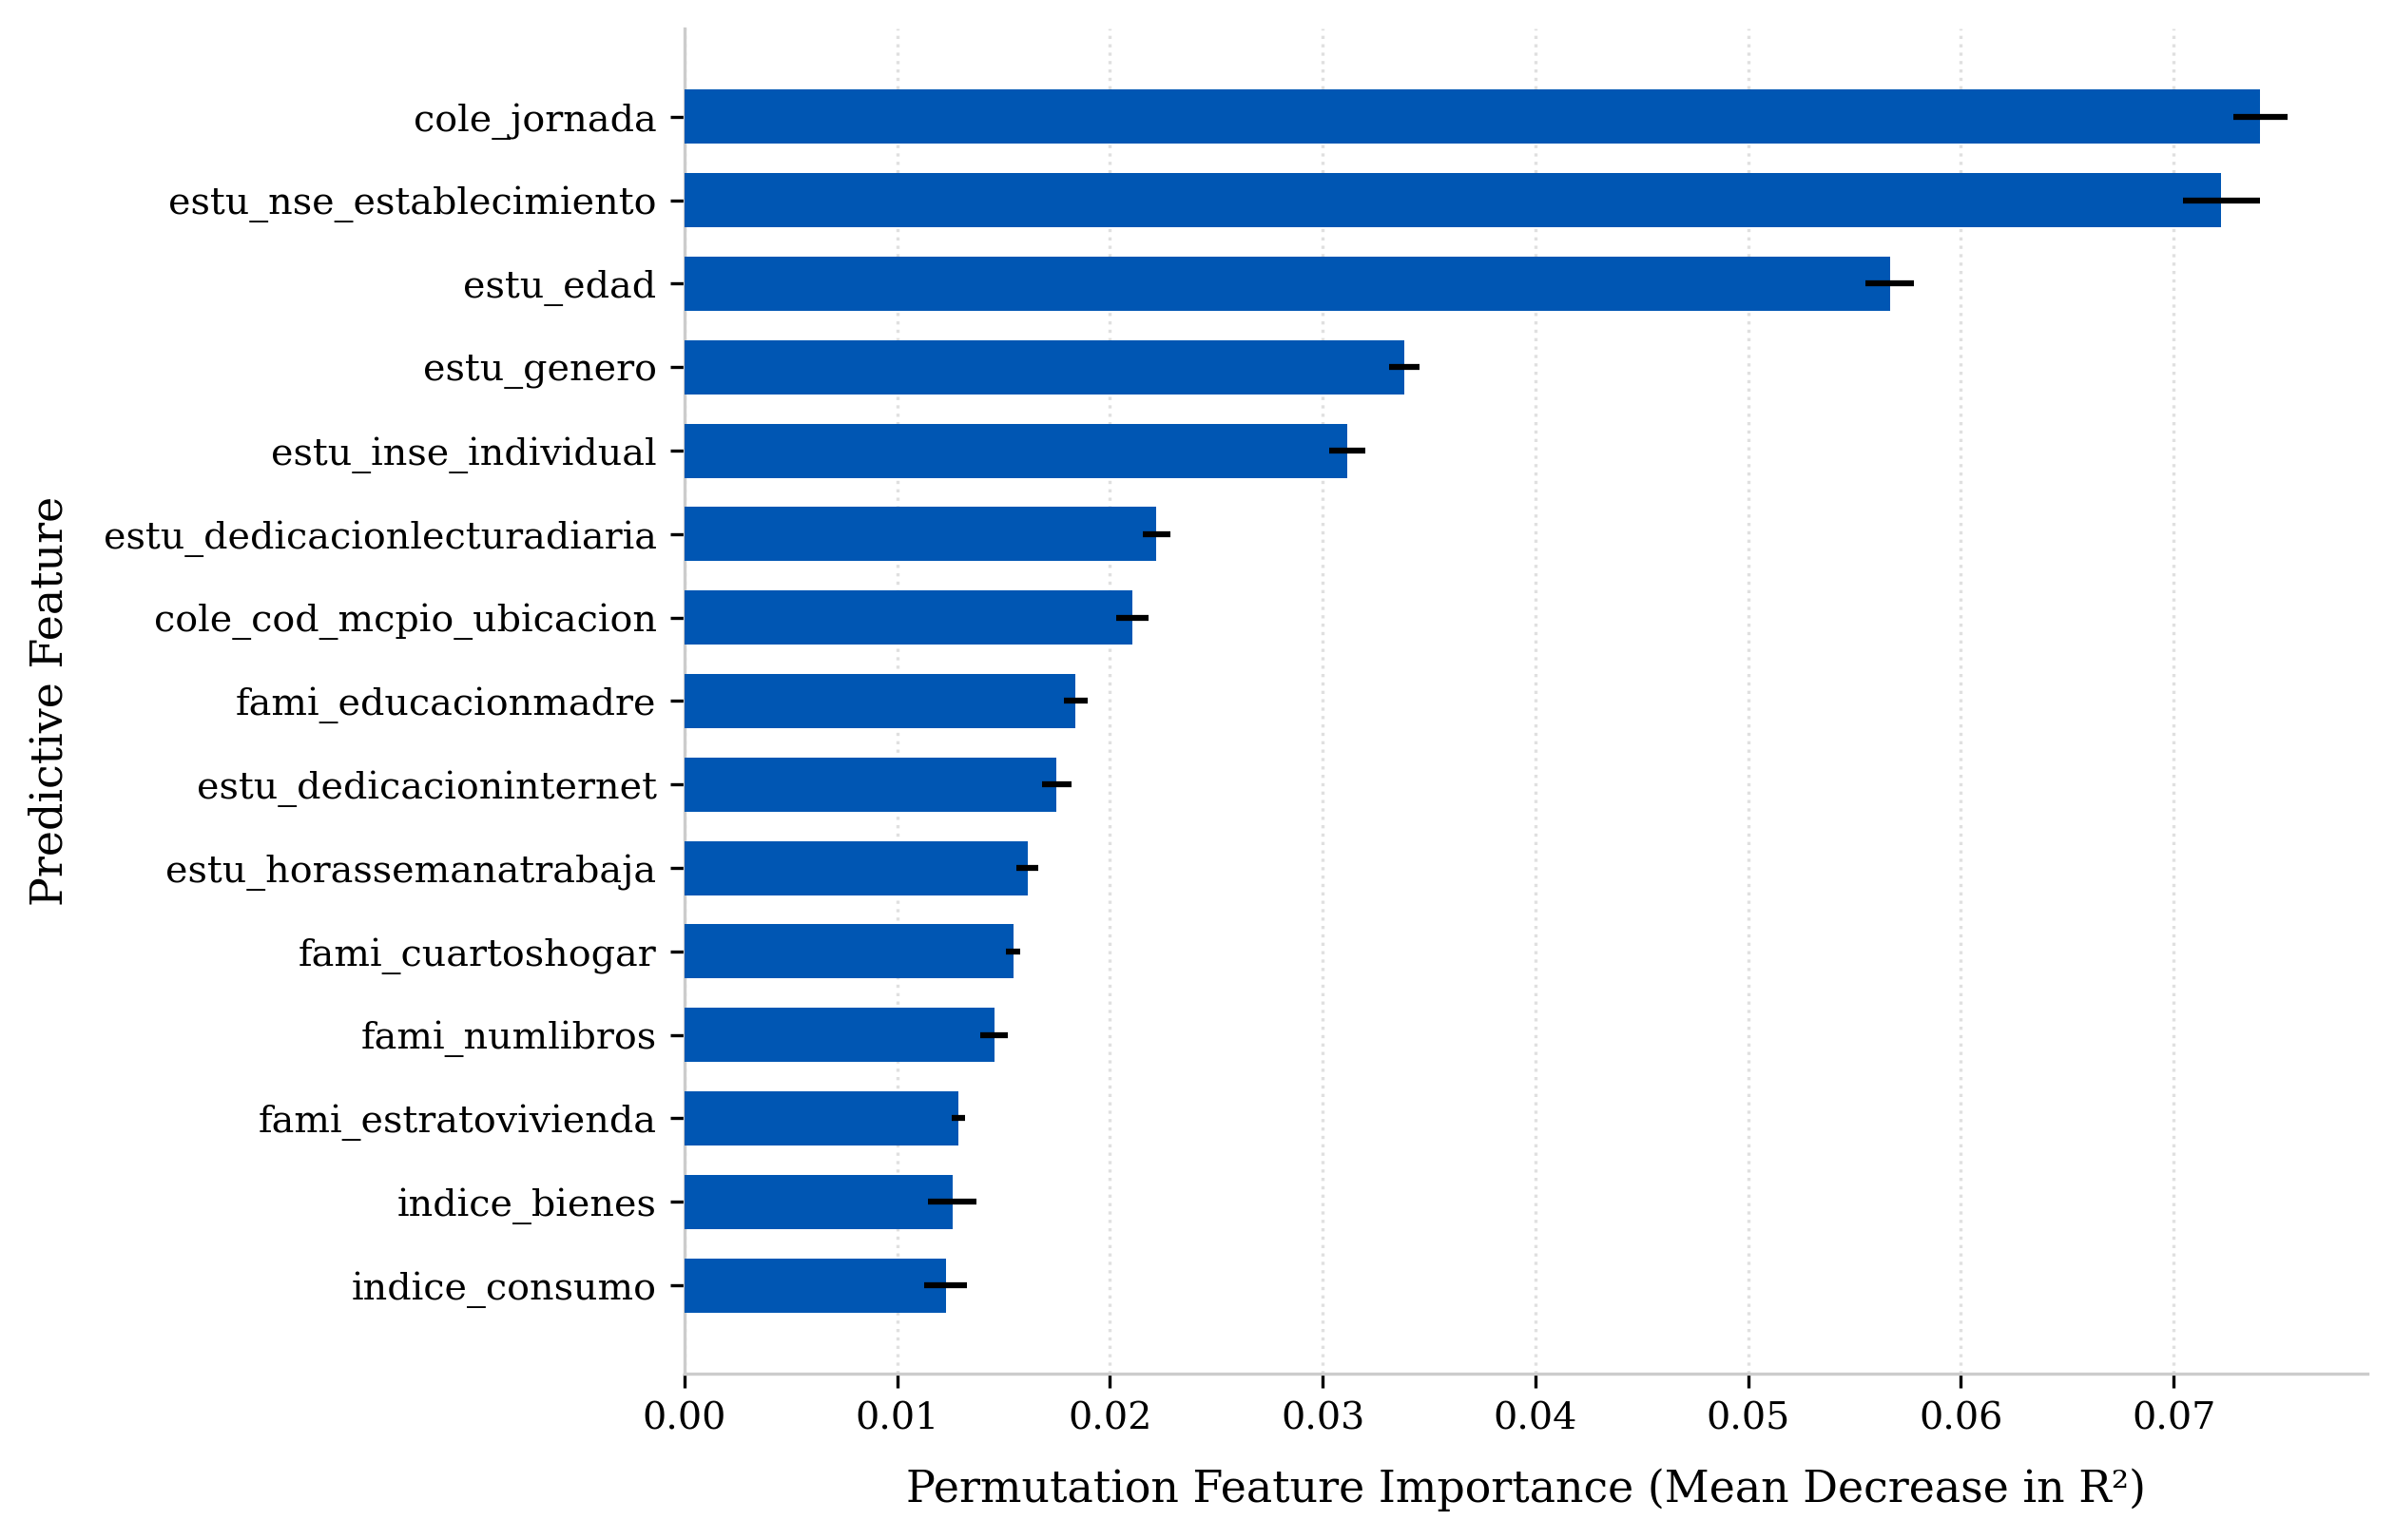


--- TOP 15 VARIABLES MÁS IMPORTANTES ---
                     Feature  Importance      Std
                cole_jornada    0.074077 0.001262
    estu_nse_establecimiento    0.072244 0.001819
                   estu_edad    0.056658 0.001143
                 estu_genero    0.033843 0.000724
        estu_inse_individual    0.031159 0.000853
estu_dedicacionlecturadiaria    0.022192 0.000638
    cole_cod_mcpio_ubicacion    0.021056 0.000754
         fami_educacionmadre    0.018397 0.000563
     estu_dedicacioninternet    0.017496 0.000696
     estu_horassemanatrabaja    0.016121 0.000525
           fami_cuartoshogar    0.015469 0.000338
              fami_numlibros    0.014563 0.000645
        fami_estratovivienda    0.012898 0.000315
               indice_bienes    0.012590 0.001128
              indice_consumo    0.012283 0.001005


In [ ]:
# ==============================================================================
# PASO 7: PERMUTATION FEATURE IMPORTANCE Y GENERACIÓN DE GRÁFICA EDITORIAL
# ==============================================================================
# Muestra representativa de prueba para cálculo ágil de permutación
X_test_sample = X_test.sample(n=25000, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

print("Calculando importancia de variables por permutación...")
perm_res = permutation_importance(
    gb_model,
    X_test_sample,
    y_test_sample,
    n_repeats=3,
    random_state=42,
    n_jobs=-1,
)

df_imp = (
    pd.DataFrame(
        {
            "Feature": X.columns,
            "Importance": perm_res.importances_mean,
            "Std": perm_res.importances_std,
        }
    )
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

top_15 = df_imp.head(15).copy()

# Configuración visual JEDM
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 11,
        "xtick.labelsize": 9.5,
        "ytick.labelsize": 9.5,
    }
)

fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=300)
y_pos = np.arange(len(top_15))
ax.barh(
    y_pos,
    top_15["Importance"],
    xerr=top_15["Std"],
    align="center",
    color="#0056b3",
    edgecolor="none",
    height=0.65,
    zorder=3,
)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_15["Feature"])
ax.invert_yaxis()

ax.set_xlabel("Permutation Feature Importance (Mean Decrease in R²)", labelpad=8)
ax.set_ylabel("Predictive Feature", labelpad=8)
ax.xaxis.grid(True, linestyle=":", alpha=0.6, color="#CCCCCC", zorder=0)
ax.yaxis.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#CCCCCC")
ax.spines["bottom"].set_color("#CCCCCC")

plt.tight_layout()
plt.savefig("gb_feature_importance.png", dpi=300, bbox_inches="tight")
plt.savefig("gb_feature_importance.pdf", format="pdf", bbox_inches="tight")
plt.show()

print("\n--- TOP 15 VARIABLES MÁS IMPORTANTES ---")
print(top_15.to_string(index=False))

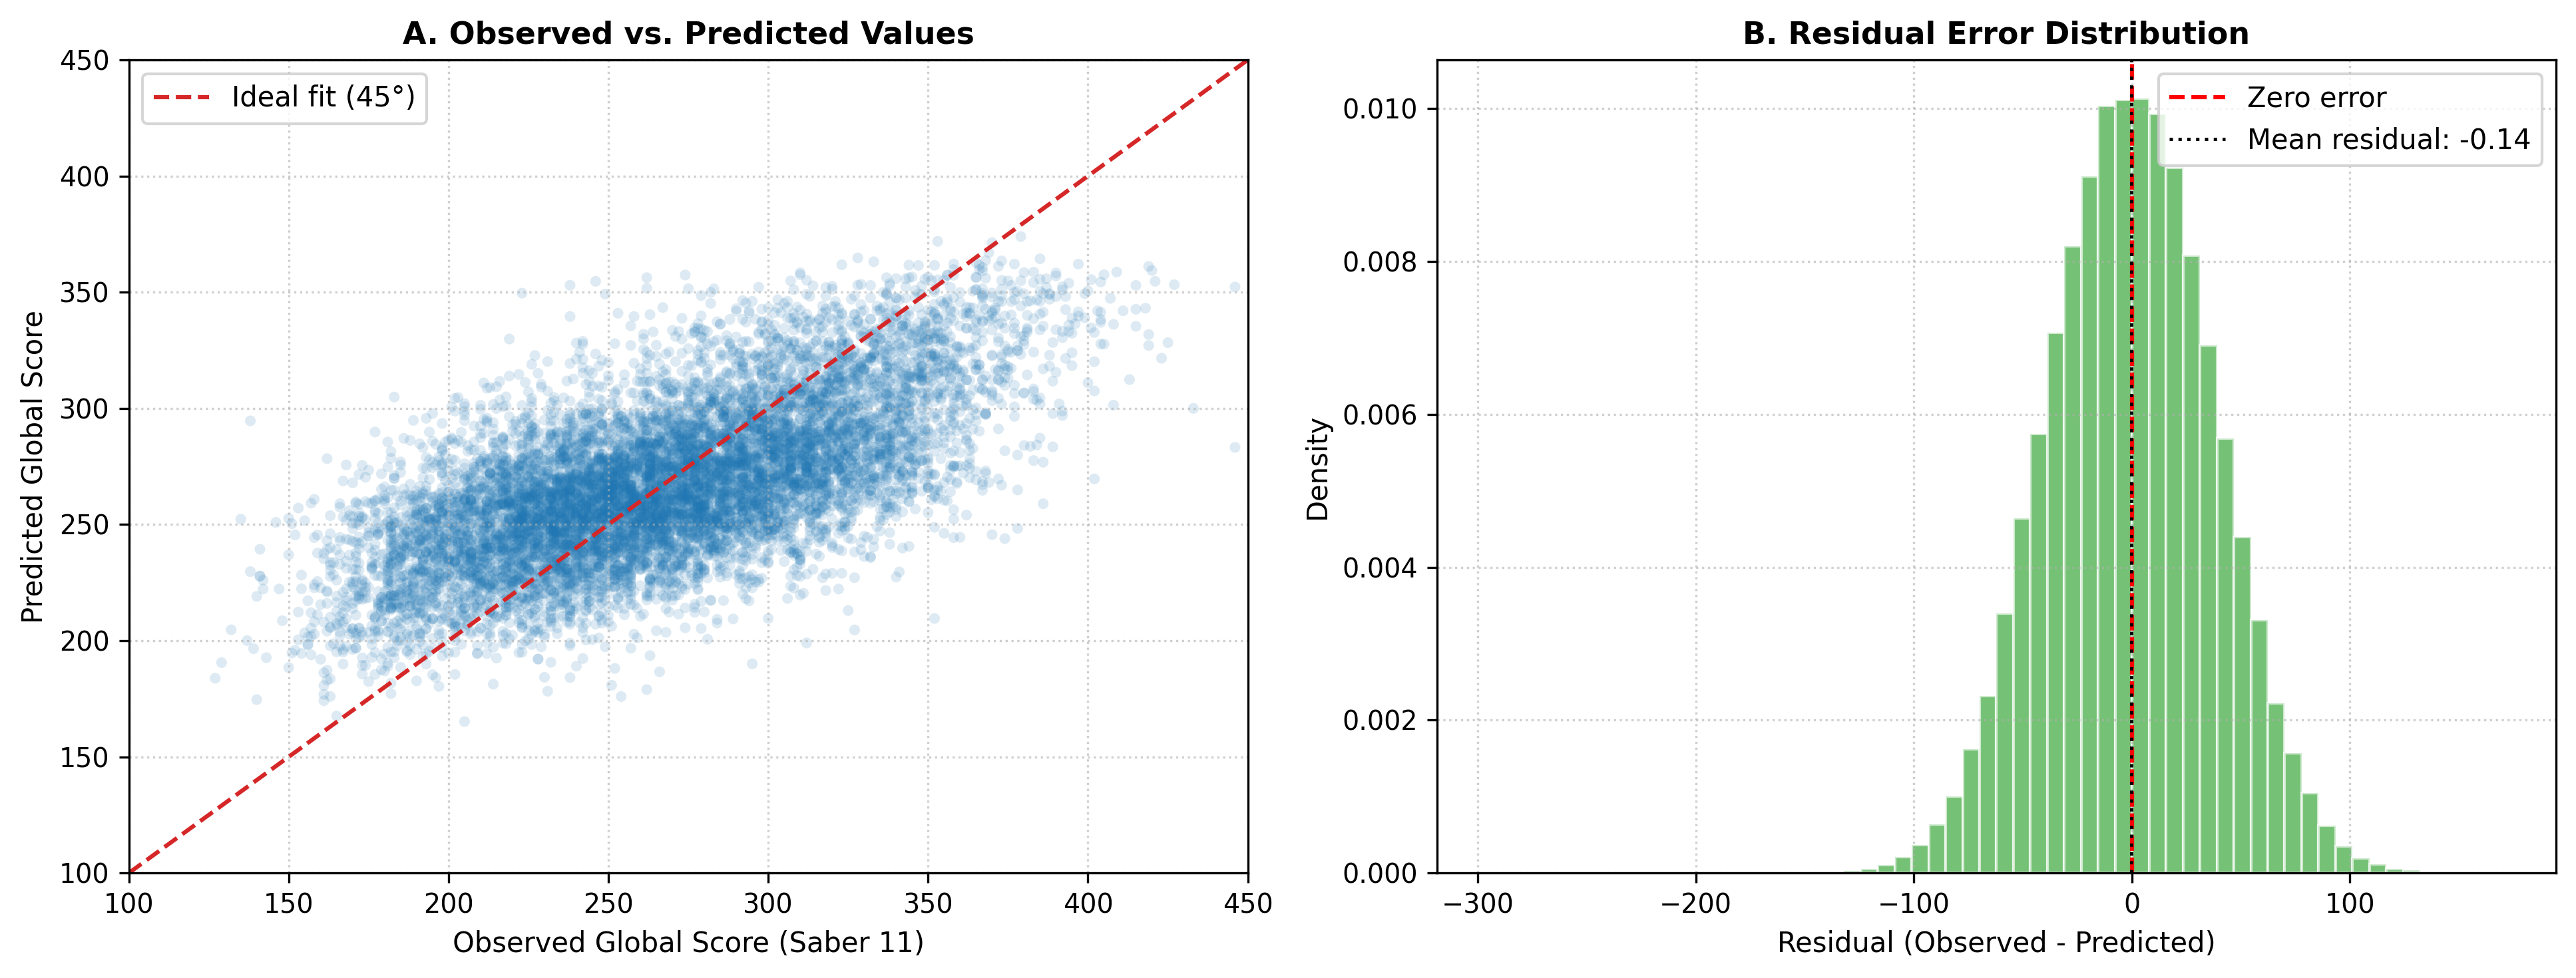

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prediction and residuals calculation on test set
y_pred = gb_model.predict(X_test)
residuos = y_test - y_pred

# 2. Editorial figure setup (English labels)
plt.rcParams["font.family"] = "sans-serif"
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=300)

# Panel A: Observed vs Predicted (representative subsample for visual clarity)
sample_indices = np.random.RandomState(42).choice(
    len(y_test), size=10000, replace=False
)
axes[0].scatter(
    y_test.iloc[sample_indices],
    y_pred[sample_indices],
    alpha=0.15,
    color="#1f77b4",
    edgecolors="none",
    s=15,
)
limits = [100, 450]
axes[0].plot(
    limits, limits, "--", color="#d62728", linewidth=1.5, label="Ideal fit (45°)"
)
axes[0].set_xlim(limits)
axes[0].set_ylim(limits)
axes[0].set_title(
    "A. Observed vs. Predicted Values", fontsize=11, fontweight="bold"
)
axes[0].set_xlabel("Observed Global Score (Saber 11)", fontsize=10)
axes[0].set_ylabel("Predicted Global Score", fontsize=10)
axes[0].legend(loc="upper left", frameon=True)
axes[0].grid(True, linestyle=":", alpha=0.6)

# Panel B: Residual error distribution
axes[1].hist(
    residuos,
    bins=60,
    density=True,
    color="#2ca02c",
    alpha=0.65,
    edgecolor="white",
)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero error")
axes[1].axvline(
    residuos.mean(),
    color="black",
    linestyle=":",
    linewidth=1.2,
    label=f"Mean residual: {residuos.mean():.2f}",
)
axes[1].set_title(
    "B. Residual Error Distribution", fontsize=11, fontweight="bold"
)
axes[1].set_xlabel("Residual (Observed - Predicted)", fontsize=10)
axes[1].set_ylabel("Density", fontsize=10)
axes[1].legend(loc="upper right", frameon=True)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.savefig("figure_3_residual_analysis.png", dpi=300, bbox_inches="tight")
plt.show()